Temporal autocorrelation analysis
=======================
Estimating the covariance of different task position pairs and seeing how short a run should be to optimally utilize the interspersed design

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
import os
import OptimalBattery.util as ut
from OptimalBattery.global_config import data_path, save_dir


# build transition matrix for visualization only...

In [3]:
dat_file = df = pd.read_csv(f"{data_path}/Cerebellum/super_cerebellum/sc1/data/s16/sc1_s16.dat", delim_whitespace=True, header=0)
filtered_dat = dat_file[dat_file["runNum"] >= 51].copy()
filtered_dat["run"] = filtered_dat["runNum"] - 50
filtered_dat = filtered_dat.drop(columns=["runNum"])
filtered_dat = filtered_dat.rename(columns={"taskName": "task_name"})

# Cerebellum

In [5]:
# define atlas and dirs
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run , info_mdtb_1_run ,task_column_name = 'cond_name',center_condition='rest')
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)
n_sub, n_reg,n_vox = data_mdtb_s1_run.shape

cond_vec = info_mdtb_1_run['cond_num'].values
part_vec  = info_mdtb_1_run["run"].values

# Remove task mean from each task condition for all runs
data_residual = data_mdtb_s1_run.copy()
for t in np.unique(cond_vec):
    mask = (cond_vec == t)
    task_mean = data_mdtb_s1_run[:, mask, :].mean(axis=1, keepdims=True)
    data_residual[:, mask, :] = data_mdtb_s1_run[:, mask, :] - task_mean
    

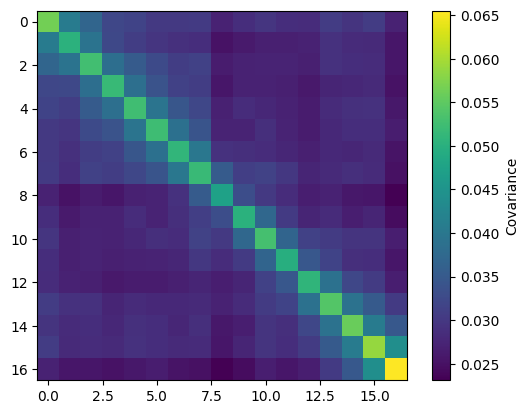

In [6]:
# add true order to info
info_with_order = ut.add_original_order(info_mdtb_1_run,filtered_dat)

# get the sort order based on (run, task_num_orig)
sort_order = info_with_order.sort_values(by=["run", "task_num_orig"]).index


# resort the info and data using the task_num_orig
info_sorted = info_with_order.loc[sort_order].reset_index(drop=True)
data_sorted = data_residual[:, sort_order, :]


n_runs = len(np.unique(info_sorted["run"]))
n_tasks = len(np.unique(info_sorted["task_num_orig"]))

cov_mats_runs = np.zeros((n_sub, n_runs, n_tasks, n_tasks))
for r, run in enumerate(np.unique(info_sorted["run"])):
    mask = info_sorted["run"].values == run
    conds = info_sorted.loc[mask, "task_num_orig"].values

    for s in range(n_sub):
        X = data_sorted[s, mask, :] 
        cov_mats_runs[s, r] = np.cov(X, rowvar=True)

# Average across runs for each subject, ignoring zeros (rest)
cov_mats_per_subj = np.zeros((n_sub, n_tasks, n_tasks))
for s in range(n_sub):
    mats = cov_mats_runs[s]
    # set zeros to nan before averaging
    mats[mats == 0] = np.nan
    cov_mats_per_subj[s] = np.nanmean(mats, axis=0)


cov_mat_avg = cov_mats_per_subj.mean(axis=0)

plt.imshow(cov_mat_avg, cmap='viridis')
plt.colorbar(label='Covariance')


In [7]:
# collect by lag
lags = np.arange(1, n_tasks)   # 1..16
mean_by_lag = np.zeros((n_sub, len(lags)))

for s in range(n_sub):
    cov_mat = cov_mats_per_subj[s]
    for j, lag in enumerate(lags):
        vals = []
        for i in range(n_tasks - lag):
            vals.append(cov_mat[i, i+lag])
        mean_by_lag[s, j] = np.nanmean(vals)

# mean and SEM across subjects
mean_across_subj = np.nanmean(mean_by_lag, axis=0)
sem_across_subj = np.nanstd(mean_by_lag, axis=0) / np.sqrt(n_sub)



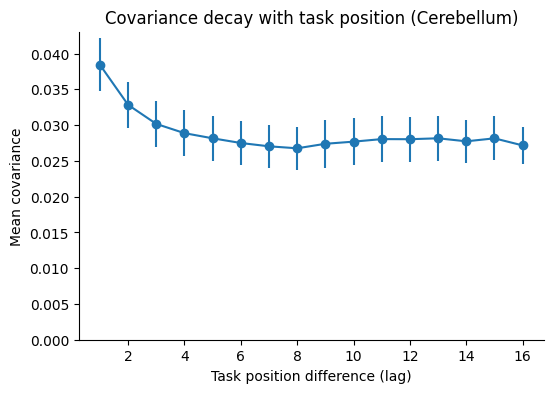

In [8]:
plt.figure(figsize=(6,4))
plt.errorbar(lags, mean_across_subj, yerr=sem_across_subj, marker='o')
plt.xlabel("Task position difference (lag)")
plt.ylabel("Mean covariance")
plt.title("Covariance decay with task position (Cerebellum)")
plt.ylim(bottom=0)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

# Cortex

In [10]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run , info_mdtb_1_run ,task_column_name = 'cond_name',center_condition='rest')
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)
n_sub, n_reg,n_vox = data_mdtb_s1_run.shape

cond_vec = info_mdtb_1_run['cond_num'].values
part_vec  = info_mdtb_1_run["run"].values

# Remove task mean from each task condition for all runs
data_residual = data_mdtb_s1_run.copy()
for t in np.unique(cond_vec):
    mask = (cond_vec == t)
    task_mean = data_mdtb_s1_run[:, mask, :].mean(axis=1, keepdims=True)
    data_residual[:, mask, :] = data_mdtb_s1_run[:, mask, :] - task_mean

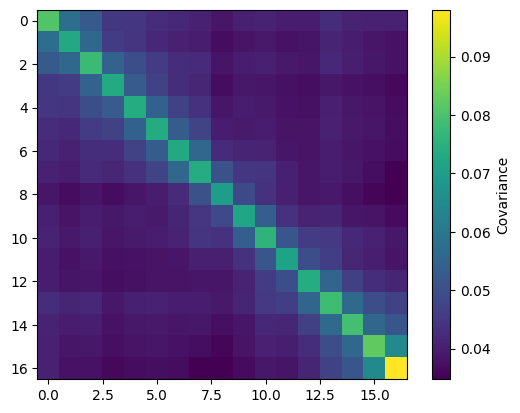

In [11]:
# add true order to info
info_with_order = ut.add_original_order(info_mdtb_1_run,filtered_dat)

# get the sort order based on (run, task_num_orig)
sort_order = info_with_order.sort_values(by=["run", "task_num_orig"]).index


# resort the info and data using the task_num_orig
info_sorted = info_with_order.loc[sort_order].reset_index(drop=True)
data_sorted = data_residual[:, sort_order, :]


n_runs = len(np.unique(info_sorted["run"]))
n_tasks = len(np.unique(info_sorted["task_num_orig"]))

cov_mats_runs = np.zeros((n_sub, n_runs, n_tasks, n_tasks))
for r, run in enumerate(np.unique(info_sorted["run"])):
    mask = info_sorted["run"].values == run
    conds = info_sorted.loc[mask, "task_num_orig"].values

    for s in range(n_sub):
        X = data_sorted[s, mask, :] 
        cov_mats_runs[s, r] = np.cov(X, rowvar=True)

# Average across runs for each subject, ignoring zeros (rest)
cov_mats_per_subj = np.zeros((n_sub, n_tasks, n_tasks))
for s in range(n_sub):
    mats = cov_mats_runs[s]
    # set zeros to nan before averaging
    mats[mats == 0] = np.nan
    cov_mats_per_subj[s] = np.nanmean(mats, axis=0)


cov_mat_avg = cov_mats_per_subj.mean(axis=0)

plt.imshow(cov_mat_avg, cmap='viridis')
plt.colorbar(label='Covariance')


In [12]:
# collect by lag
lags = np.arange(1, n_tasks)   # 1..16
mean_by_lag = np.zeros((n_sub, len(lags)))

for s in range(n_sub):
    cov_mat = cov_mats_per_subj[s]
    for j, lag in enumerate(lags):
        vals = []
        for i in range(n_tasks - lag):
            vals.append(cov_mat[i, i+lag])
        mean_by_lag[s, j] = np.nanmean(vals)

# mean and SEM across subjects
mean_across_subj = np.nanmean(mean_by_lag, axis=0)
sem_across_subj = np.nanstd(mean_by_lag, axis=0) / np.sqrt(n_sub)


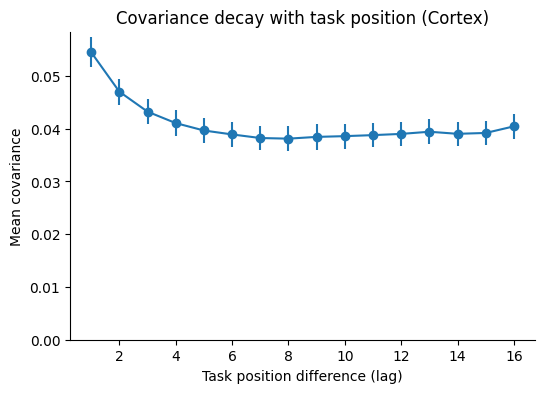

In [19]:
plt.figure(figsize=(6, 4))
plt.errorbar(lags, mean_across_subj, yerr=sem_across_subj, marker='o')
plt.xlabel("Task position difference (lag)")
plt.ylabel("Mean covariance")
plt.title("Covariance decay with task position (Cortex)")
plt.ylim(bottom=0)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(f"{save_dir}/carryover_tempAutocorrelation/temp_auto.pdf", bbox_inches='tight')
plt.show()